In [1]:
import pandas as pd
import NLProcessing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
import re 

font_path = "fonts"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [2]:
METRICS = [
    "PI_Hg_OSAR", 
    "Light Attraction Index_Hg_OSAR", "Log2 Speed ratio_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR", "Bout Number Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR",
    "Max Velocity ratio_Hg_OSAR"
]

METRIC_DISPLAY = {
    "PI_Hg_OSAR": "PI", "Light Attraction Index_Hg_OSAR": "Light Attraction Index",
    "Log2 Speed ratio_Hg_OSAR": r"$\mathrm{Log_2}$ Speed Ratio", 
    "Log2 Bout Speed ratio_Hg_OSAR": r"$\mathrm{Log_2}$ Bout Speed Ratio", 
    "Bout Number Index_Hg_OSAR": "Bout Number Index", "Bout Duration ratio_Hg_OSAR": "Bout Duration Ratio",
    "Max Velocity ratio_Hg_OSAR": "Max Velocity Ratio"
}

## Functions

In [ ]:
from vortexmap import *


## Code

In [4]:
data_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled\Bootstrapped stats"

responders = ["ACR", "Chrimson2"]
osar_data = load_bootstrap_data(data_path, responders=responders)
exclude = ['R76B09', 'VT999036']
[[osar_data[r][m].pop(key, None) for r in osar_data for m in osar_data[r] for key in exclude]];

In [7]:
responder = "ACR"

mbon_csv_path = "MBONlist.csv"
lobelocation = NLProcessing.generate_lobelocation(mbons, "MBONlist.csv")

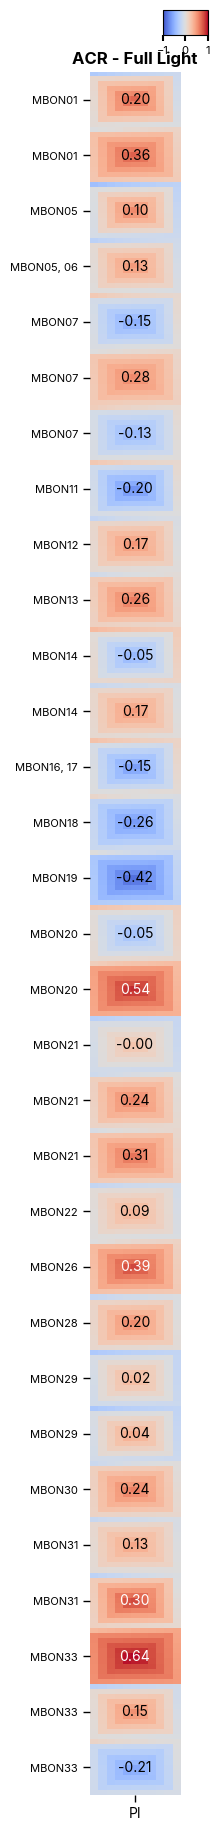

In [35]:
# Single metric
metrics_to_plot = ["PI_Hg_OSAR"]

spirals, mean_vals, mbons = build_vortex_df(osar_data, responder, metrics_to_plot, lobelocation)
fig, ax = vortex_map(spirals, mean_vals, cmap='coolwarm', vmin=-1, vmax=1,
                     figsize=(2, 18), annot=True, annot_fontsize=10)

ylabels = create_labels(mbons, lobelocation, sep='\n')
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xticklabels([METRIC_DISPLAY.get(m, m) for m in metrics_to_plot], fontsize=10)
ax.set_title(f"{responder} - Full Light", fontsize=12, fontweight='bold')

# Fix ghost ticks
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', length=5, width=1, color='black')
ax.tick_params(axis='both', which='minor', length=0, width=0)

# Colorbar
cax = inset_axes(ax, width="50%", height="1.5%", loc='upper right',
                 bbox_to_anchor=(0, 0.02, 1, 1), bbox_transform=ax.transAxes, borderpad=-2)
cbar = fig.colorbar(ax.images[0], cax=cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=8, width=1.5, length=4)
cbar.set_ticks([-1, 0, 1])

plt.tight_layout()
plt.show()

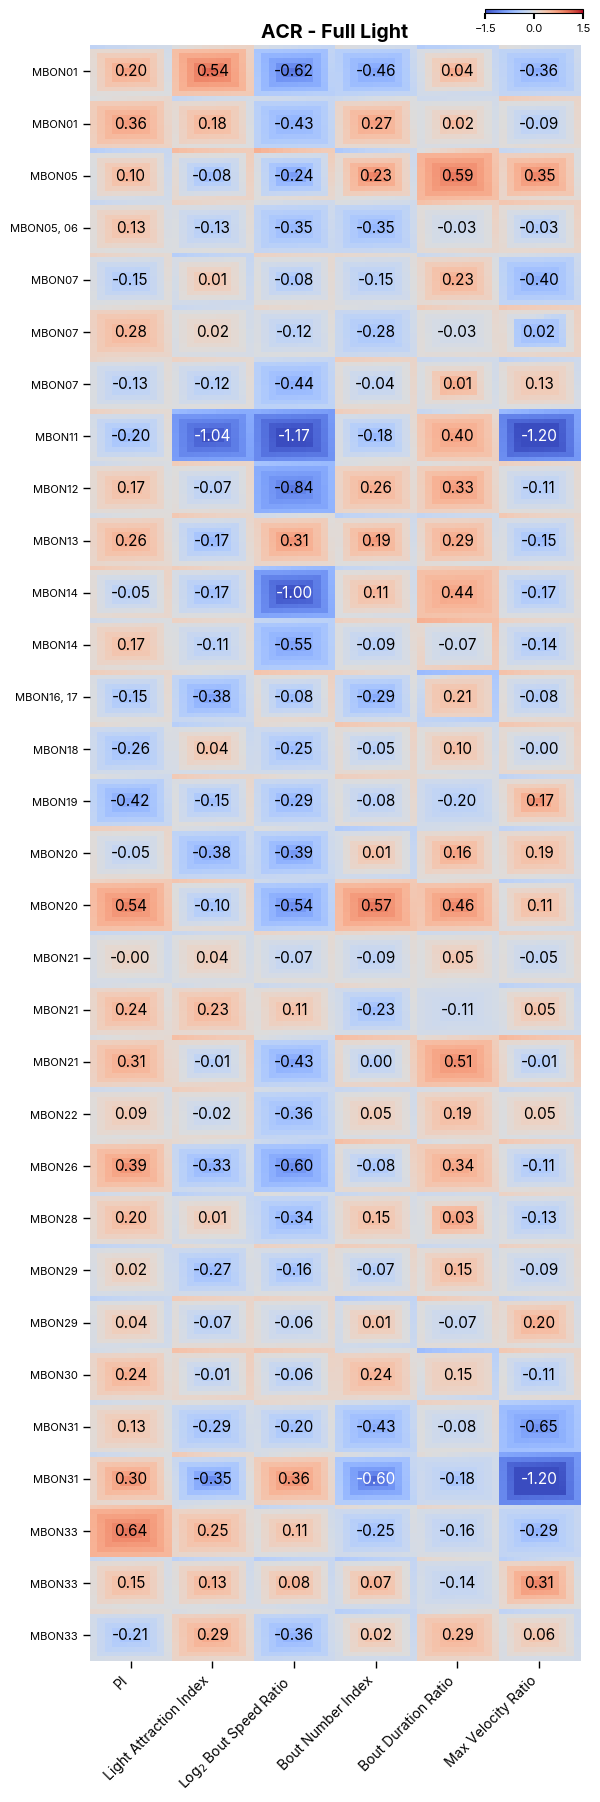

In [36]:
# All metrics in one heatmap
spirals, mean_vals, mbons = build_vortex_df(osar_data, responder, METRICS, lobelocation)
fig, ax = vortex_map(spirals, mean_vals, cmap='coolwarm', vmin=-1.5, vmax=1.5,
                     figsize=(6, 18), annot=True, annot_fontsize=11)

ylabels = create_labels(mbons, lobelocation, sep='\n')
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xticklabels([METRIC_DISPLAY.get(m, m) for m in METRICS], fontsize=10, rotation=45, ha='right')
ax.set_title(f"{responder} - Full Light", fontsize=14, fontweight='bold')

# Fix ghost ticks
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', length=5, width=1, color='black')
ax.tick_params(axis='both', which='minor', length=0, width=0)

# Colorbar
cax = inset_axes(ax, width="20%", height="1%", loc='upper right',
                 bbox_to_anchor=(-0.05, 0.805, 1, 0.2), bbox_transform=ax.transAxes, borderpad=-2)
cbar = fig.colorbar(ax.images[0], cax=cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=8, width=1.5, length=4)
cbar.set_ticks([-1.5, 0, 1.5])

plt.tight_layout()
plt.show()

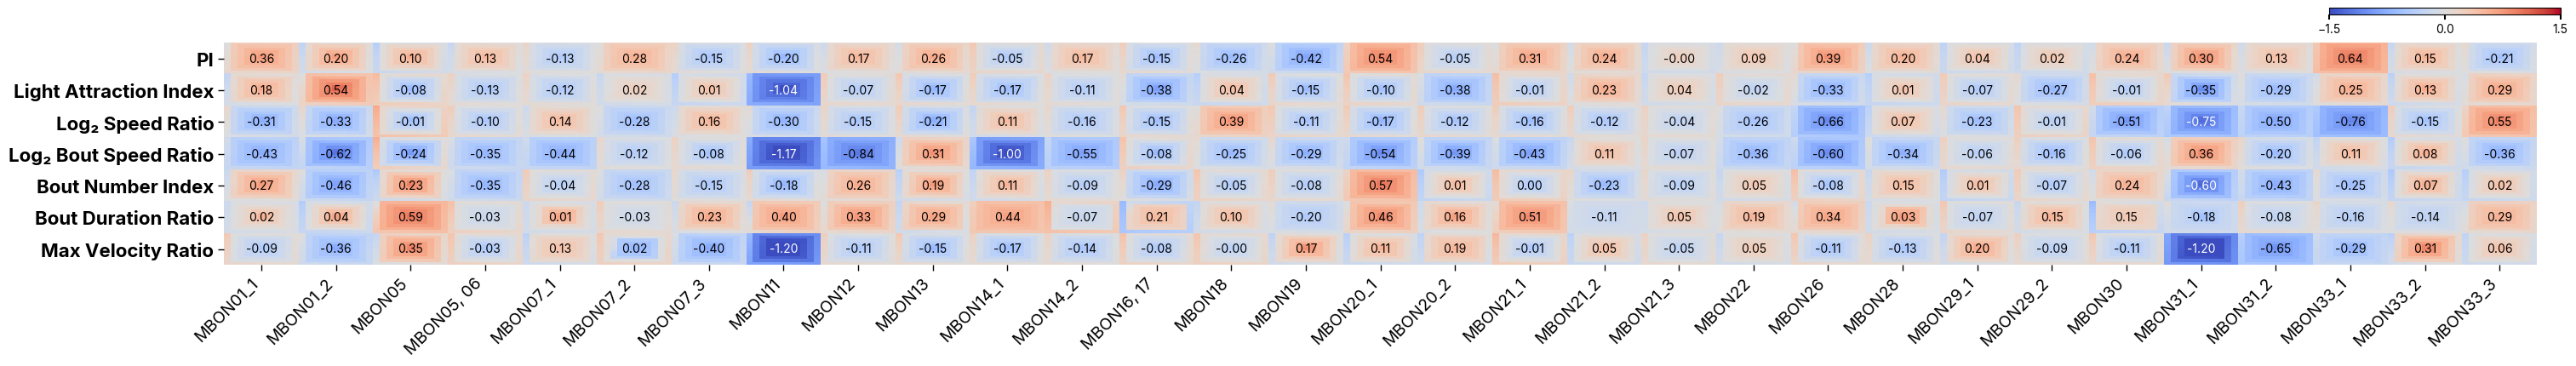

In [8]:
METRIC_DISPLAY = {
    "PI_Hg_OSAR": "PI", "Light Attraction Index_Hg_OSAR": "Light Attraction Index",
    "Log2 Speed ratio_Hg_OSAR": "Log\u2082 Speed Ratio", 
    "Log2 Bout Speed ratio_Hg_OSAR": "Log\u2082 Bout Speed Ratio", 
    "Bout Number Index_Hg_OSAR": "Bout Number Index", "Bout Duration ratio_Hg_OSAR": "Bout Duration Ratio",
    "Max Velocity ratio_Hg_OSAR": "Max Velocity Ratio"
}

# All metrics in one heatmap — TRANSPOSED (MBONs on x-axis, Metrics on y-axis)
spirals, mean_vals, mbons = build_vortex_df(osar_data, responder, METRICS, lobelocation)

if responder == "ACR":
    responderrename = "GtACR1"
if responder == 'Chrimson2':
    responderrename = 'CsChrimson'
    
# Transpose spirals and mean_vals
spirals_T = spirals.T
mean_vals_T = mean_vals.T
n = 11

fig, ax = vortex_map(spirals_T, mean_vals_T, cmap='coolwarm', vmin=-1.5, vmax=1.5,
                     figsize=(30, 4), annot=True, annot_fontsize=10)

xlabels = create_mbon_only_labels(mbons, lobelocation)
n_cols = len(mbons)
n_rows = len(METRICS)

# Explicitly re-set ticks to avoid ghost ticks
ax.set_xticks([j*n + (n-1)/2 for j in range(n_cols)])
ax.set_xticklabels(xlabels, fontsize=14, rotation=45, ha='right')
ax.set_yticks([i*n + (n-1)/2 for i in range(n_rows)])
ax.set_yticklabels([METRIC_DISPLAY.get(m, m) for m in METRICS], fontsize=16, fontweight = 'bold')
#ax.set_title(f"{responderrename}", fontsize=15, fontweight='bold')

# Fix ghost ticks
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', length=5, width=1, color='black')
ax.tick_params(axis='both', which='minor', length=0, width=0)


# Colorbar (horizontal)
cax = inset_axes(ax, width="10%", height="3%", loc='upper right',
                 bbox_to_anchor=(0, 0.05, 1, 1), bbox_transform=ax.transAxes, borderpad=-2)
cbar = fig.colorbar(ax.images[0], cax=cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=10, width=1.5, length=4)
cbar.set_ticks([-1.5, 0, 1.5])

plt.tight_layout()
plt.show()